# Importing the Cleaned data

In [1]:
import pandas as pd 
df = pd.read_pickle(r"C:\Users\gabri\Documents\Data Analysis\Github\StayInsight\01. Data\02. Clean Data\airbnb_paris_combined_cleaned.pkl")
print(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

  type_of_day  cost_2pax_2night  cost_2pax_1night        room_type  bedrooms  \
0     weekday        296.159940        148.079970     Private room         1   
1     weekday        288.237487        144.118744     Private room         1   
2     weekday        211.343089        105.671544     Private room         1   
3     weekday        298.956100        149.478050  Entire home/apt         1   
4     weekday        247.926181        123.963091  Entire home/apt         1   

   person_capacity  host_is_superhost  cleanliness_rating  \
0              2.0               True                10.0   
1              2.0               True                10.0   
2              2.0              False                10.0   
3              2.0              False                 9.0   
4              4.0              False                 7.0   

   guest_satisfaction_overall  longitude  latitude  distance_km  
0                        97.0    2.35385  48.86282     0.699821  
1                   

In [5]:
palette = {
    "navy": "#1A1A2E",
    "amber": "#E8A020",
    "amber_dark": "#BA7517",
    "amber_light": "#FAEEDA",
    "blue": "#185FA5",
    "teal": "#5DCAA5",
    "gray": "#888780"
}

# Converting to CSV  fo compatibality 

In [2]:
df = pd.read_pickle(r"c:\Users\Desmond\Downloads\airbnb_paris_combined_cleaned.pkl")
df.to_csv(r"c:\Users\Desmond\Downloads\airbnb_clean.csv", index=False)
print(" Saved as CSV - reload anytime!")

 Saved as CSV - reload anytime!


Checking the Cloumns

In [3]:
df.describe()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6688 entries, 0 to 6687
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   type_of_day                 6688 non-null   str    
 1   cost_2pax_2night            6688 non-null   float64
 2   cost_2pax_1night            6688 non-null   float64
 3   room_type                   6688 non-null   str    
 4   bedrooms                    6688 non-null   int64  
 5   person_capacity             6688 non-null   float64
 6   host_is_superhost           6688 non-null   bool   
 7   cleanliness_rating          6688 non-null   float64
 8   guest_satisfaction_overall  6688 non-null   float64
 9   longitude                   6688 non-null   float64
 10  latitude                    6688 non-null   float64
 11  distance_km                 6688 non-null   float64
dtypes: bool(1), float64(8), int64(1), str(2)
memory usage: 581.4 KB


In [4]:
print("\nSuperhost counts:")
print(df['host_is_superhost'].value_counts())


Superhost counts:
host_is_superhost
False    5747
True      941
Name: count, dtype: int64


In [5]:
print(df.columns.tolist())
print(df.dtypes)
print(df.info())

['type_of_day', 'cost_2pax_2night', 'cost_2pax_1night', 'room_type', 'bedrooms', 'person_capacity', 'host_is_superhost', 'cleanliness_rating', 'guest_satisfaction_overall', 'longitude', 'latitude', 'distance_km']
type_of_day                       str
cost_2pax_2night              float64
cost_2pax_1night              float64
room_type                         str
bedrooms                        int64
person_capacity               float64
host_is_superhost                bool
cleanliness_rating            float64
guest_satisfaction_overall    float64
longitude                     float64
latitude                      float64
distance_km                   float64
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 6688 entries, 0 to 6687
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   type_of_day                 6688 non-null   str    
 1   cost_2pax_2night            6688 non-null   f

Verification

In [6]:
print(df[['host_is_superhost', 'guest_satisfaction_overall', 'cleanliness_rating', 'cost_2pax_1night']].head())


   host_is_superhost  guest_satisfaction_overall  cleanliness_rating  \
0               True                        97.0                10.0   
1               True                        97.0                10.0   
2              False                        94.0                10.0   
3              False                        91.0                 9.0   
4              False                        82.0                 7.0   

   cost_2pax_1night  
0        148.079970  
1        144.118744  
2        105.671544  
3        149.478050  
4        123.963091  


In [7]:
summary = df.groupby('host_is_superhost')[['guest_satisfaction_overall', 'cleanliness_rating', 'cost_2pax_1night']].agg(['mean', 'median', 'count'])
print(summary.round(2))


                  guest_satisfaction_overall              cleanliness_rating  \
                                        mean median count               mean   
host_is_superhost                                                              
False                                  91.30   93.0  5747               9.18   
True                                   96.55   97.0   941               9.78   

                               cost_2pax_1night                
                  median count             mean  median count  
host_is_superhost                                              
False                9.0  5747           194.75  156.47  5747  
True                10.0   941           205.49  170.45   941  


Carrying out the Test 

In [8]:
summary = df.groupby('host_is_superhost')[['guest_satisfaction_overall', 'cleanliness_rating', 'cost_2pax_1night']].agg(['mean', 'median', 'count'])
print("\nHypothesis test:")
print(summary.round(2))



Hypothesis test:
                  guest_satisfaction_overall              cleanliness_rating  \
                                        mean median count               mean   
host_is_superhost                                                              
False                                  91.30   93.0  5747               9.18   
True                                   96.55   97.0   941               9.78   

                               cost_2pax_1night                
                  median count             mean  median count  
host_is_superhost                                              
False                9.0  5747           194.75  156.47  5747  
True                10.0   941           205.49  170.45   941  


In [9]:
satisfaction = df.groupby('host_is_superhost')['guest_satisfaction_overall'].agg(['mean', 'median', 'count'])
cleanliness = df.groupby('host_is_superhost')['cleanliness_rating'].agg(['mean', 'median', 'count'])
price = df.groupby('host_is_superhost')['cost_2pax_1night'].agg(['mean', 'median', 'count'])

print(satisfaction.round(2))
print(cleanliness.round(2))
print(price.round(2))

                    mean  median  count
host_is_superhost                      
False              91.30    93.0   5747
True               96.55    97.0    941
                   mean  median  count
host_is_superhost                     
False              9.18     9.0   5747
True               9.78    10.0    941
                     mean  median  count
host_is_superhost                       
False              194.75  156.47   5747
True               205.49  170.45    941


Customer Satisfaction Visual 

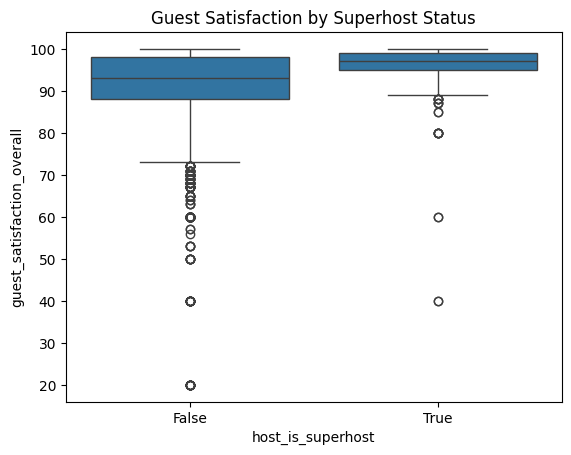

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='host_is_superhost', y='guest_satisfaction_overall')
plt.title('Guest Satisfaction by Superhost Status')
plt.show()

Saving to Machine 

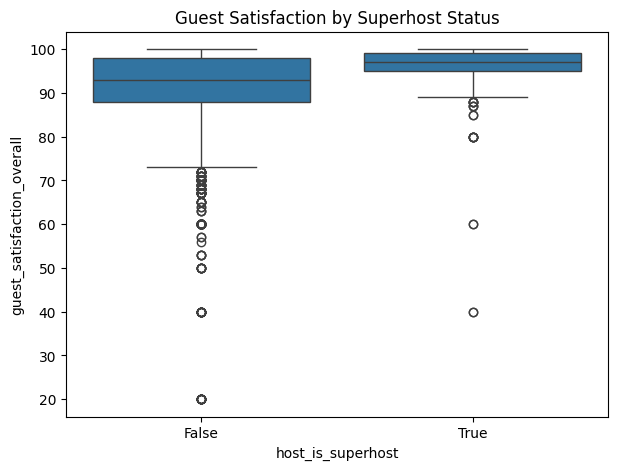

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='host_is_superhost', y='guest_satisfaction_overall', ax=ax)
ax.set_title('Guest Satisfaction by Superhost Status')
fig.savefig(r'C:\Users\Desmond\Downloads\guest_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

Visual for Cleanliness Rating 


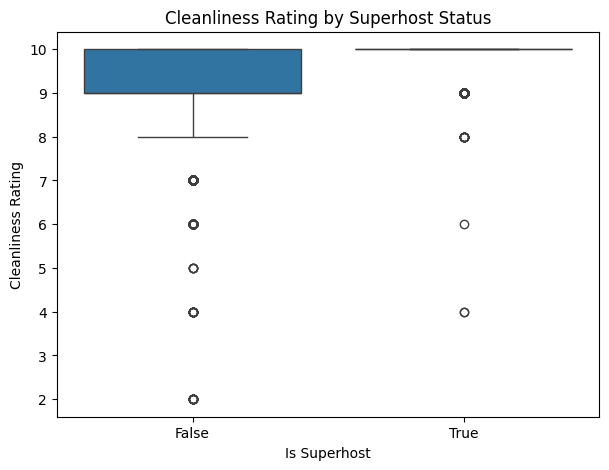

In [12]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='host_is_superhost', y='cleanliness_rating')
plt.title('Cleanliness Rating by Superhost Status')
plt.xlabel('Is Superhost')
plt.ylabel('Cleanliness Rating')
plt.show()

Saving to Machine 

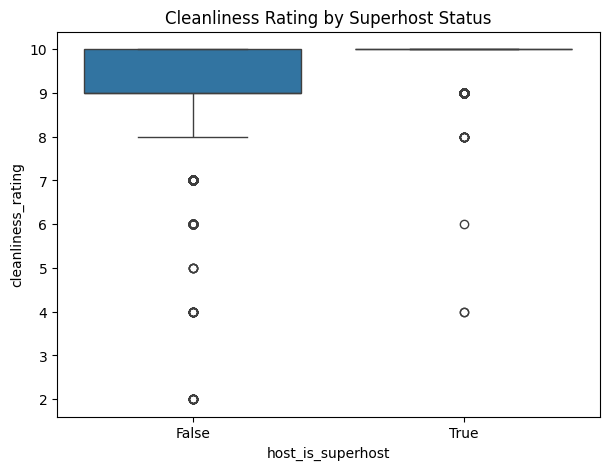

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='host_is_superhost', y='cleanliness_rating', ax=ax)
ax.set_title('Cleanliness Rating by Superhost Status')
fig.savefig(r'C:\Users\Desmond\Downloads\cleanliness_rating.png', dpi=300, bbox_inches='tight')
plt.show()

Visual For Price 

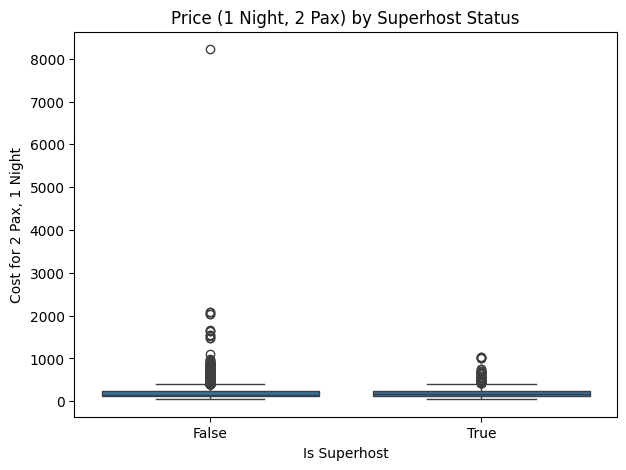

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='host_is_superhost', y='cost_2pax_1night')
plt.title('Price (1 Night, 2 Pax) by Superhost Status')
plt.xlabel('Is Superhost')
plt.ylabel('Cost for 2 Pax, 1 Night')
plt.show()

Saving to Machine 

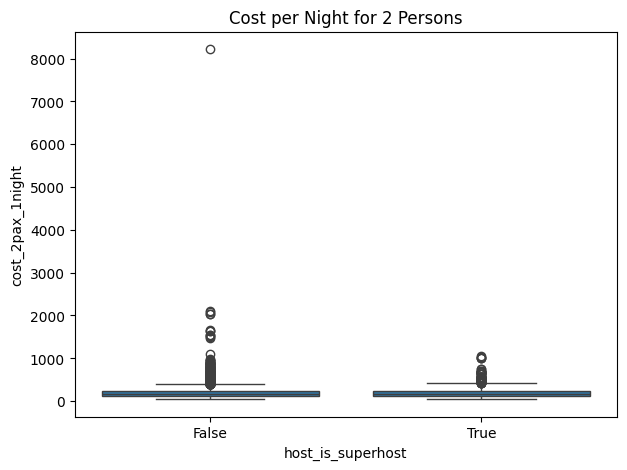

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='host_is_superhost', y='cost_2pax_1night', ax=ax)
ax.set_title('Cost per Night for 2 Persons')
fig.savefig(r'C:\Users\Desmond\Downloads\cost_per_night.png', dpi=300, bbox_inches='tight')
plt.show()

All together 

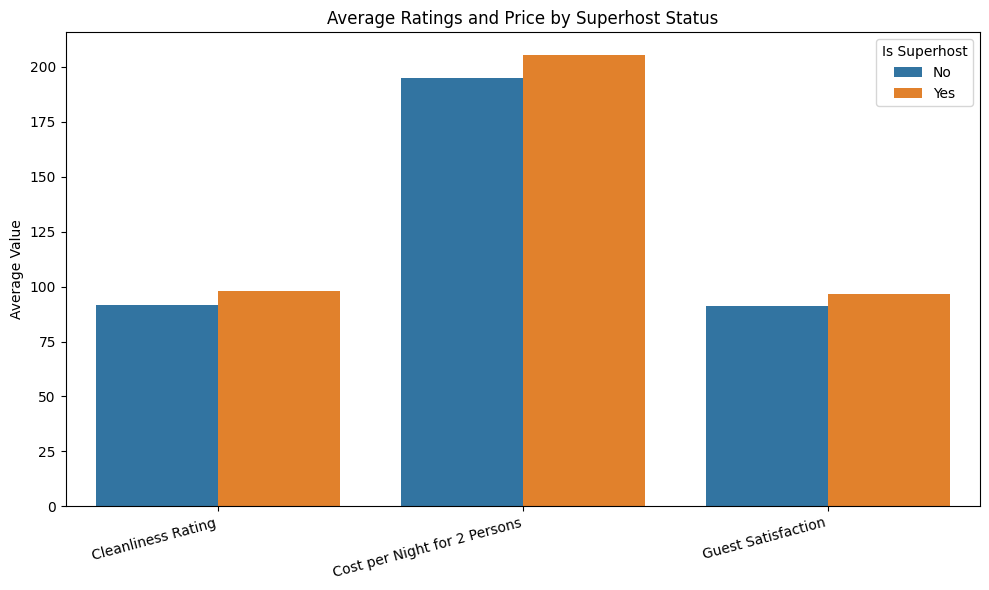

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'guest_satisfaction_overall',
    'cleanliness_rating',
    'cost_2pax_1night',
]

df['host_is_superhost'] = df['host_is_superhost'].replace({True: 'Yes', False: 'No', 'True': 'Yes', 'False': 'No'})

plot_df = df[['host_is_superhost'] + cols].copy()
plot_df['cleanliness_rating'] = plot_df['cleanliness_rating'] * 10

plot_df = plot_df.melt(
    id_vars='host_is_superhost',
    var_name='metric',
    value_name='value'
)

summary = plot_df.groupby(['host_is_superhost', 'metric'], as_index=False)['value'].mean()

label_map = {
    'guest_satisfaction_overall': 'Guest Satisfaction',
    'cleanliness_rating': 'Cleanliness Rating',
    'cost_2pax_1night': 'Cost per Night for 2 Persons'
}

summary['metric'] = summary['metric'].replace(label_map)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=summary,
    x='metric',
    y='value',
    hue='host_is_superhost'
)

ax.set_title('Average Ratings and Price by Superhost Status')
ax.set_xlabel('')
ax.set_ylabel('Average Value')
ax.tick_params(axis='x', rotation=15)
plt.setp(ax.get_xticklabels(), ha='right')

plt.legend(title='Is Superhost')
plt.tight_layout()
plt.show()

Saving to Machine 

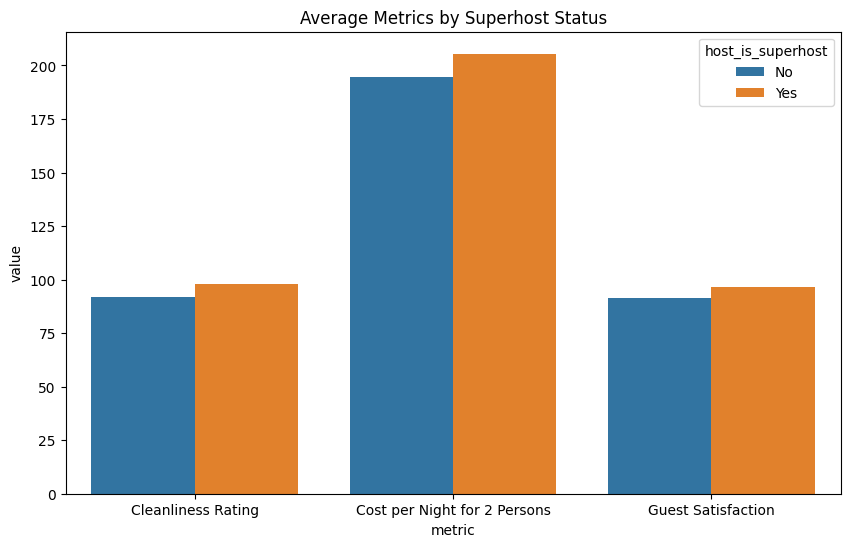

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=summary, x='metric', y='value', hue='host_is_superhost', ax=ax)
ax.set_title('Average Metrics by Superhost Status')
fig.savefig(r'C:\Users\Desmond\Downloads\bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2898762403.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


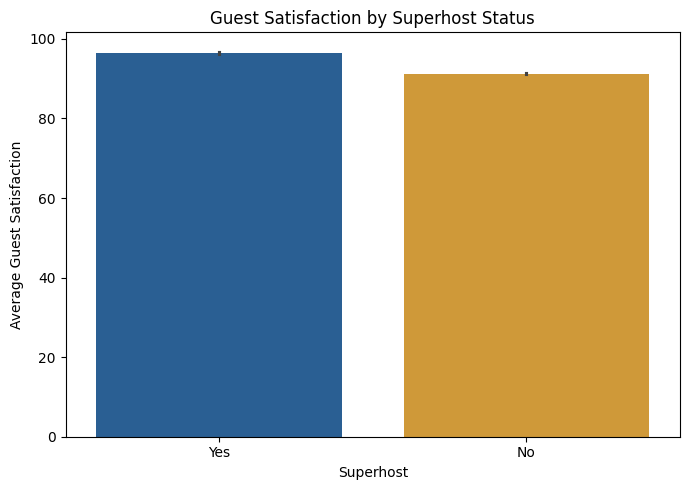

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2898762403.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


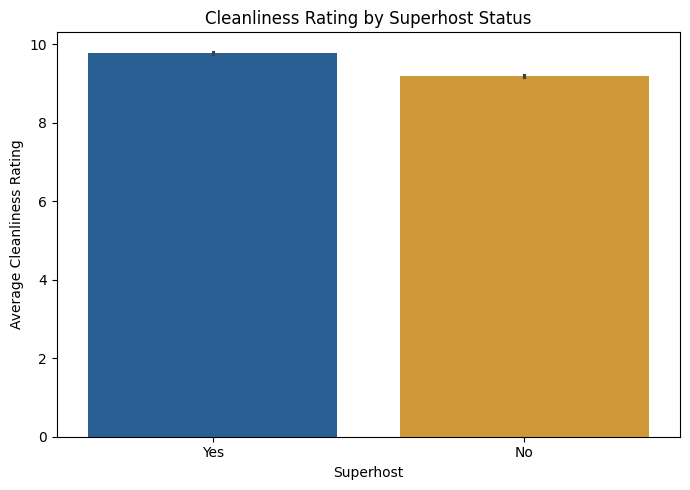

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2898762403.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


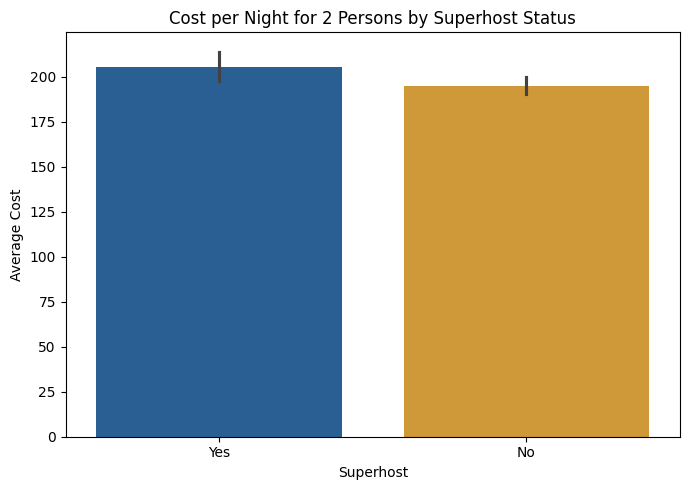

In [19]:

df['host_is_superhost'] = df['host_is_superhost'].replace({
    True: 'Yes',
    False: 'No',
    'True': 'Yes',
    'False': 'No'
})

palette = ['#185FA5', '#E8A020']


fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='guest_satisfaction_overall',
    ax=ax,
    palette=palette
)
ax.set_title('Guest Satisfaction by Superhost Status')
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Guest Satisfaction')
fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\guest_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='cleanliness_rating',
    ax=ax,
    palette=palette
)
ax.set_title('Cleanliness Rating by Superhost Status')
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Cleanliness Rating')
fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\cleanliness_rating.png', dpi=300, bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='cost_2pax_1night',
    ax=ax,
    palette=palette
)
ax.set_title('Cost per Night for 2 Persons by Superhost Status')
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Cost')
fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\cost_per_night.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2834037023.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


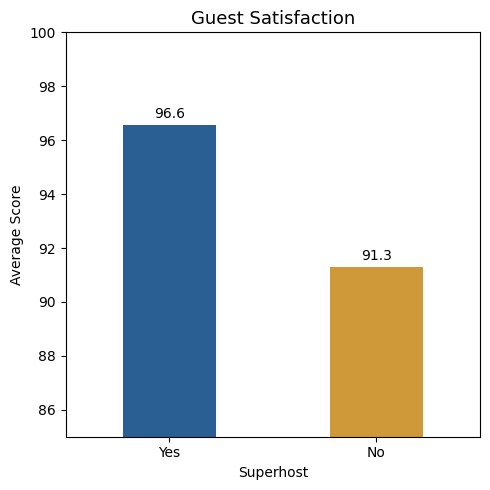

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2834037023.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


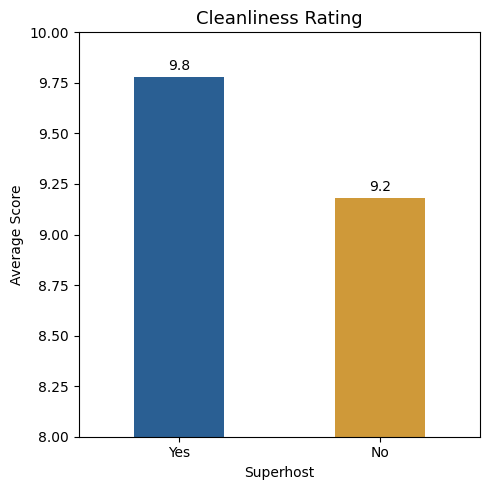

C:\Users\Desmond\AppData\Local\Temp\ipykernel_8928\2834037023.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


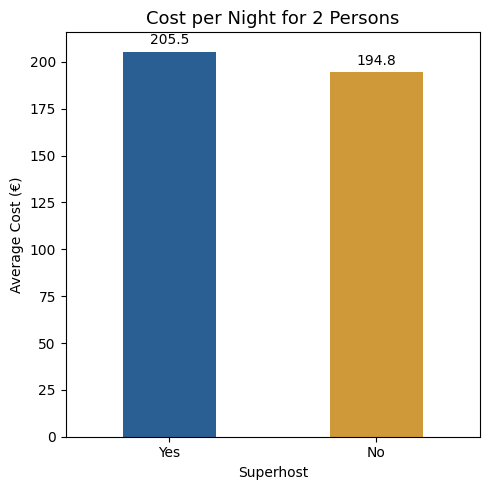

In [20]:

df['host_is_superhost'] = df['host_is_superhost'].replace({
    True: 'Yes',
    False: 'No',
    'True': 'Yes',
    'False': 'No'
})

palette = ['#185FA5', '#E8A020']

# 1) Guest Satisfaction
fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='guest_satisfaction_overall',
    estimator='mean',
    errorbar=None,
    palette=palette,
    width=0.45,
    ax=ax
)
ax.set_title('Guest Satisfaction', fontsize=13)
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Score')
ax.set_ylim(85, 100)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\guest_satisfaction.png', dpi=300, bbox_inches='tight')
plt.show()

# 2) Cleanliness Rating
fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='cleanliness_rating',
    estimator='mean',
    errorbar=None,
    palette=palette,
    width=0.45,
    ax=ax
)
ax.set_title('Cleanliness Rating', fontsize=13)
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Score')
ax.set_ylim(8, 10)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\cleanliness_rating.png', dpi=300, bbox_inches='tight')
plt.show()

# 3) Cost per Night for 2 Persons
fig, ax = plt.subplots(figsize=(5, 5))
sns.barplot(
    data=df,
    x='host_is_superhost',
    y='cost_2pax_1night',
    estimator='mean',
    errorbar=None,
    palette=palette,
    width=0.45,
    ax=ax
)
ax.set_title('Cost per Night for 2 Persons', fontsize=13)
ax.set_xlabel('Superhost')
ax.set_ylabel('Average Cost (€)')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

fig.tight_layout()
fig.savefig(r'C:\Users\Desmond\Downloads\cost_per_night.png', dpi=300, bbox_inches='tight')
plt.show()

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df.head()

,type_of_day,cost_2pax_2night,cost_2pax_1night,room_type,bedrooms,person_capacity,host_is_superhost,cleanliness_rating,guest_satisfaction_overall,longitude,latitude,distance_km
0,weekday,296.159940,148.079970,Private room,1,2.0,True,10.0,97.0,2.35385,48.86282,0.699821
1,weekday,288.237487,144.118744,Private room,1,2.0,True,10.0,97.0,2.32436,48.85902,2.100005
2,weekday,211.343089,105.671544,Private room,1,2.0,False,10.0,94.0,2.31714,48.87475,3.302325
3,weekday,298.956100,149.478050,Entire home/apt,1,2.0,False,9.0,91.0,2.35600,48.86100,0.547567
4,weekday,247.926181,123.963091,Entire home/apt,1,4.0,False,7.0,82.0,2.35915,48.86648,1.197921


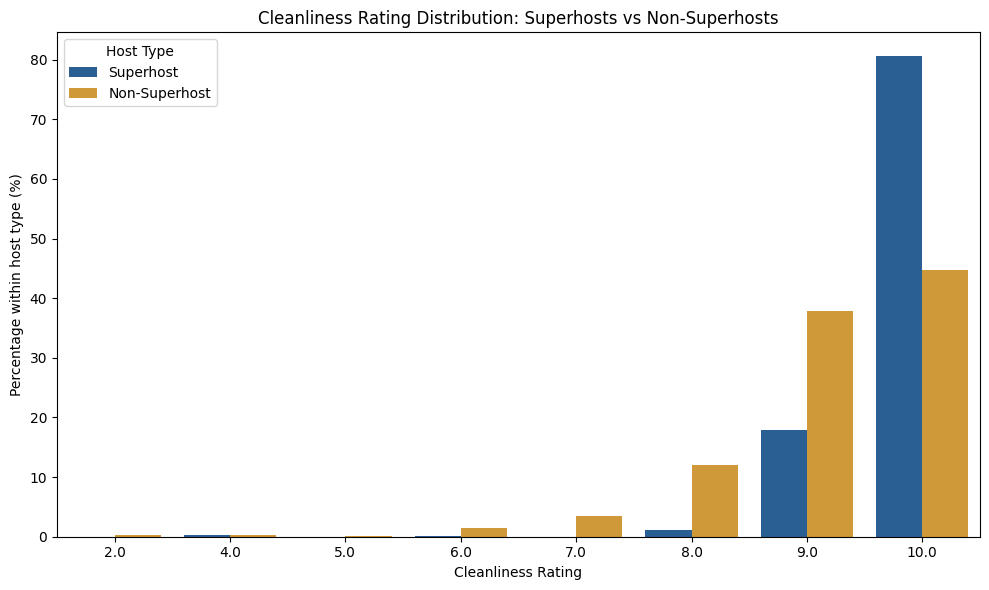

In [18]:
df['host_is_superhost'] = df['host_is_superhost'].astype(bool)

cleanliness_dist = (
    pd.crosstab(df['cleanliness_rating'], df['host_is_superhost'], normalize='columns')
    .mul(100)
    .reset_index()
    .melt(id_vars='cleanliness_rating', var_name='host_is_superhost', value_name='percentage')
)

cleanliness_dist['host_type'] = cleanliness_dist['host_is_superhost'].map({
    True: 'Superhost',
    False: 'Non-Superhost'
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cleanliness_dist,
    x='cleanliness_rating',
    y='percentage',
    hue='host_type',
    hue_order=['Superhost', 'Non-Superhost'],
    palette={'Superhost': palette['blue'], 'Non-Superhost': palette['amber']}
)

plt.title('Cleanliness Rating Distribution: Superhosts vs Non-Superhosts')
plt.xlabel('Cleanliness Rating')
plt.ylabel('Percentage within host type (%)')
plt.legend(title='Host Type')
plt.tight_layout()
plt.savefig('cleanliness_host_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

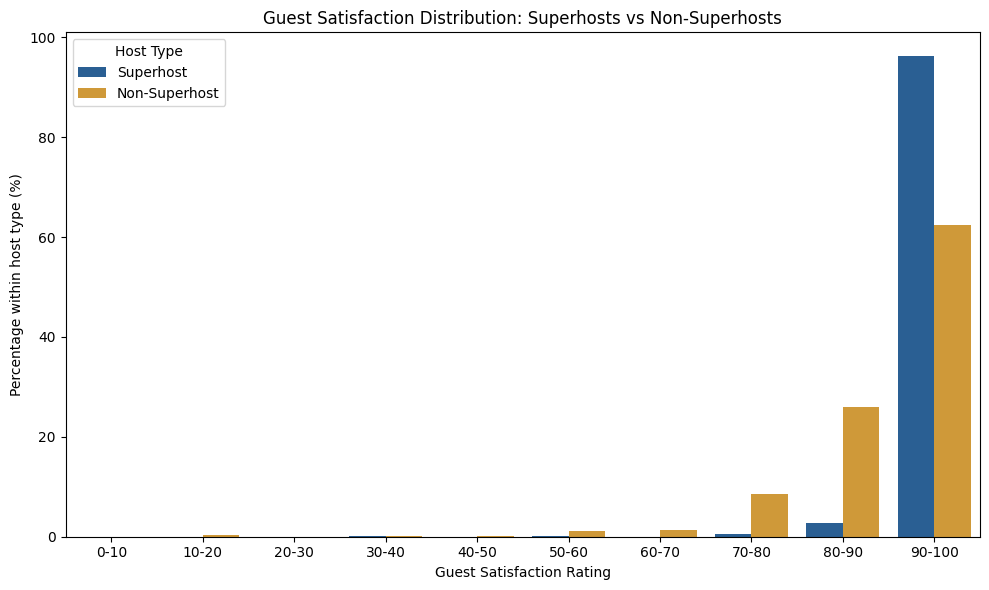

In [23]:
df['host_is_superhost'] = df['host_is_superhost'].astype(bool)

df['satisfaction_bucket'] = pd.cut(
    df['guest_satisfaction_overall'], 
    bins=range(0, 101, 10),
    right=True,
    labels=bucket_labels 
)

cleanliness_dist = (
    pd.crosstab(df['satisfaction_bucket'], df['host_is_superhost'], normalize='columns')
    .mul(100)
    .reset_index()
    .melt(id_vars='satisfaction_bucket', var_name='host_is_superhost', value_name='percentage')
)

cleanliness_dist['host_type'] = cleanliness_dist['host_is_superhost'].map({
    True: 'Superhost',
    False: 'Non-Superhost'
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cleanliness_dist,
    x='satisfaction_bucket',
    y='percentage',
    hue='host_type',
    hue_order=['Superhost', 'Non-Superhost'],
    palette={'Superhost': palette['blue'], 'Non-Superhost': palette['amber']}
)

plt.title('Guest Satisfaction Distribution: Superhosts vs Non-Superhosts')
bucket_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', 
                 '50-60', '60-70', '70-80', '80-90', '90-100']
plt.xlabel('Guest Satisfaction Rating')
plt.ylabel('Percentage within host type (%)')
plt.legend(title='Host Type')
plt.tight_layout()
plt.savefig('guest_satisfaction_host_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

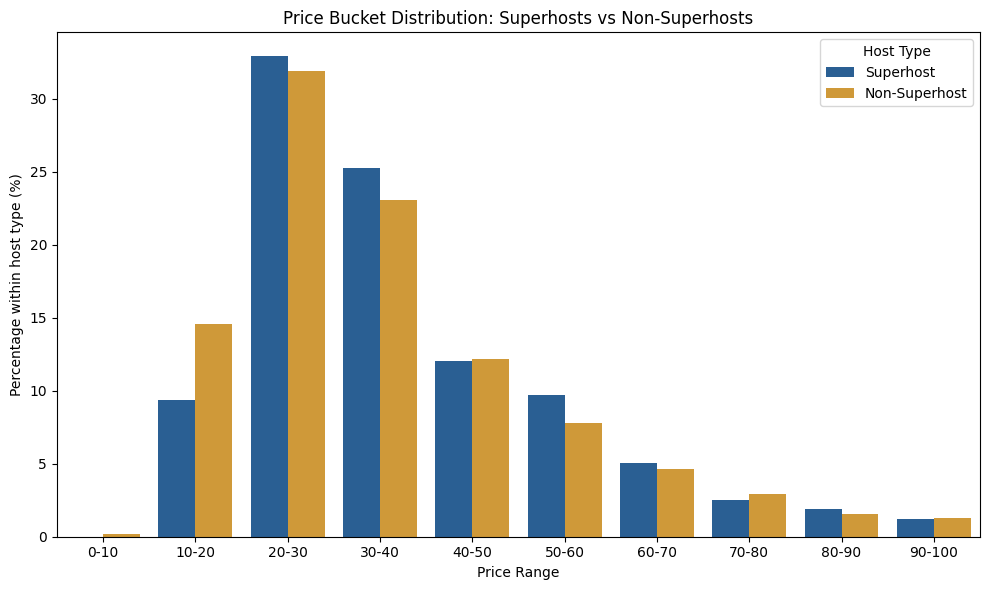

In [25]:
df['host_is_superhost'] = df['host_is_superhost'].astype(bool)

df['price_bucket'] = pd.cut(
    df['cost_2pax_1night'], 
    bins=range(0, 501, 50),  # buckets of 50: 0-50, 50-100, etc.
    right=True,
    labels=bucket_labels
)
     

cleanliness_dist = (
    pd.crosstab(df['price_bucket'], df['host_is_superhost'], normalize='columns')
    .mul(100)
    .reset_index()
    .melt(id_vars='price_bucket', var_name='host_is_superhost', value_name='percentage')
)

cleanliness_dist['host_type'] = cleanliness_dist['host_is_superhost'].map({
    True: 'Superhost',
    False: 'Non-Superhost'
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=cleanliness_dist,
    x='price_bucket',
    y='percentage',
    hue='host_type',
    hue_order=['Superhost', 'Non-Superhost'],
    palette={'Superhost': palette['blue'], 'Non-Superhost': palette['amber']}
)

plt.title('Price Bucket Distribution: Superhosts vs Non-Superhosts')
bucket_labels = ['0-50', '50-100', '100-150', '150-200', '200-250', 
                 '250-300', '300-350', '350-400', '400-450', '450-500']
plt.xlabel('Price Range')
plt.ylabel('Percentage within host type (%)')
plt.legend(title='Host Type')
plt.tight_layout()
plt.savefig('price_bucket_host_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

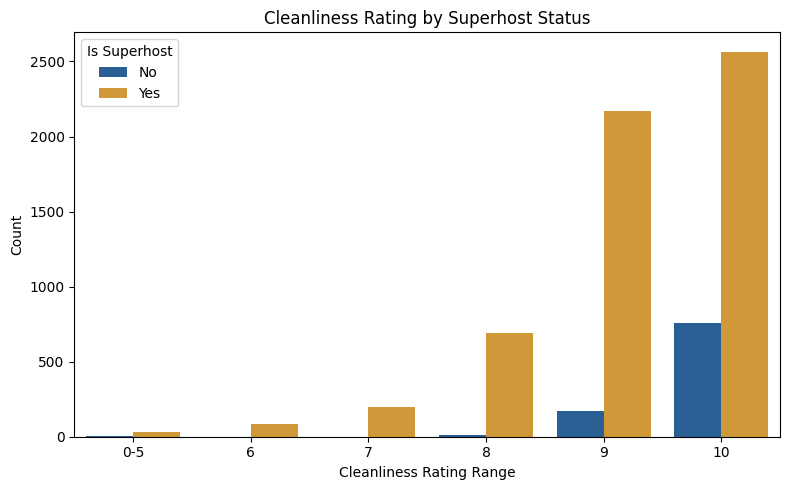

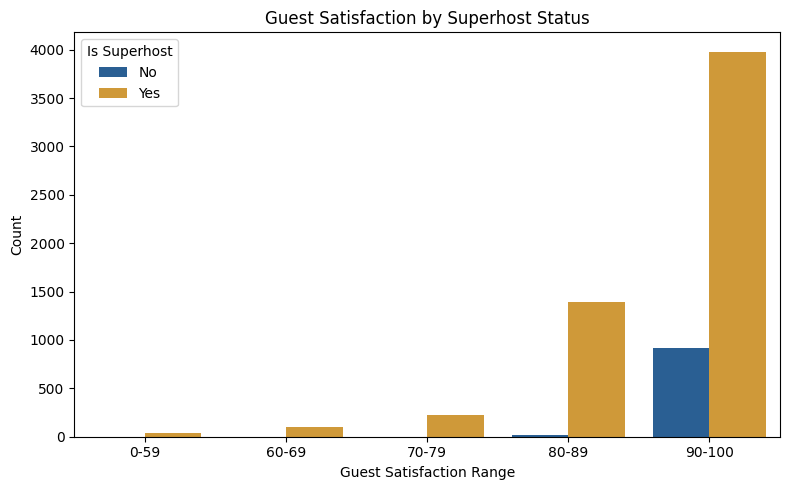

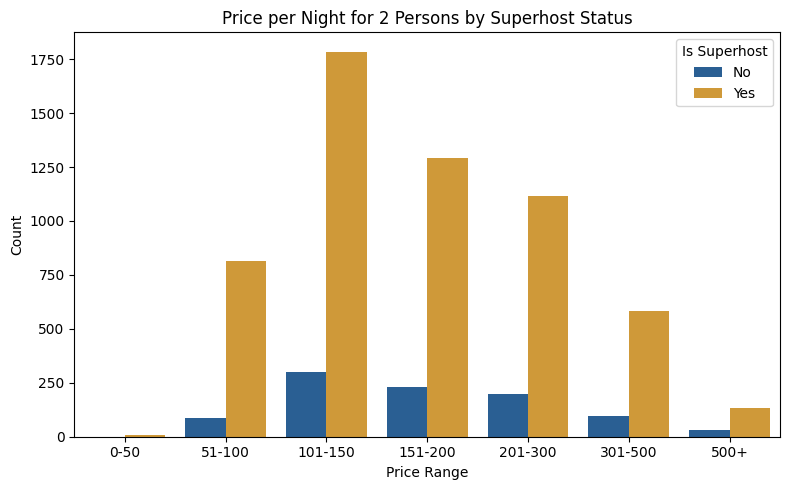

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

palette = {
    'No': '#E8A020',
    'Yes': '#185FA5'
}

df['host_is_superhost'] = df['host_is_superhost'].replace({
    True: 'Yes',
    False: 'No',
    'True': 'Yes',
    'False': 'No'
})

# -------------------------
# 1. Cleanliness bins
# -------------------------
df['cleanliness_bin'] = pd.cut(
    df['cleanliness_rating'],
    bins=[0, 5, 6, 7, 8, 9, 10],
    labels=['0-5', '6', '7', '8', '9', '10'],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='cleanliness_bin',
    hue='host_is_superhost',
    palette=palette
)

ax.set_title('Cleanliness Rating by Superhost Status')
ax.set_xlabel('Cleanliness Rating Range')
ax.set_ylabel('Count')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['No', 'Yes'], title='Is Superhost')
plt.tight_layout()
plt.show()

# -------------------------
# 2. Satisfaction bins
# -------------------------
df['satisfaction_bin'] = pd.cut(
    df['guest_satisfaction_overall'],
    bins=[0, 59, 69, 79, 89, 100],
    labels=['0-59', '60-69', '70-79', '80-89', '90-100'],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='satisfaction_bin',
    hue='host_is_superhost',
    palette=palette
)

ax.set_title('Guest Satisfaction by Superhost Status')
ax.set_xlabel('Guest Satisfaction Range')
ax.set_ylabel('Count')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['No', 'Yes'], title='Is Superhost')
plt.tight_layout()
plt.show()

# -------------------------
# 3. Price bins
# -------------------------
df['price_bin'] = pd.cut(
    df['cost_2pax_1night'],
    bins=[0, 50, 100, 150, 200, 300, 500, 1000],
    labels=['0-50', '51-100', '101-150', '151-200', '201-300', '301-500', '500+'],
    include_lowest=True
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x='price_bin',
    hue='host_is_superhost',
    palette=palette
)

ax.set_title('Price per Night for 2 Persons by Superhost Status')
ax.set_xlabel('Price Range')
ax.set_ylabel('Count')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=['No', 'Yes'], title='Is Superhost')
plt.tight_layout()
plt.show()

Checking for Skwedness 

In [18]:
print(df.skew(numeric_only=True))

cost_2pax_2night              19.411813
cost_2pax_1night              19.411813
bedrooms                       0.674062
person_capacity                0.991397
cleanliness_rating            -2.254026
guest_satisfaction_overall    -2.722238
longitude                     -0.324467
latitude                      -0.259183
distance_km                    0.299404
dtype: float64


## Findings

- Superhosts generally have higher guest satisfaction scores.
- Cleanliness ratings are also higher for superhosts.
- Price is much more skewed than the rating variables.
- A few very expensive listings create outliers in the price columns.

### Key patterns
- Most guest satisfaction scores are high.
- Most cleanliness ratings are also high.
- Price has a long right tail, so the median is more representative than the mean.

### Anomalies
- Some listings have unusually high prices.
- A small number of low-rated listings pull the satisfaction distribution left.